# Phase 4 — Evaluation

In [1]:
import sys
sys.path.append('../src')

import torch
from config import MODELS_DIR, PLOTS_DIR, METADATA_DIR
from data_loader import get_dataloaders
from models.improved_cnn import ImprovedCNN
from evaluate import get_predictions, save_predictions_csv, plot_confusion_matrix, print_top_confusions

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Load model + test data

In [2]:
train_loader, val_loader, test_loader, class_mapping = get_dataloaders()
idx_to_class = {v: k for k, v in class_mapping.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

model = ImprovedCNN(num_classes=len(class_mapping)).to(device)
ckpt_path = MODELS_DIR / 'improved' / 'improved_best.pt'
model.load_state_dict(torch.load(ckpt_path, map_location=device))
print(f"Loaded: {ckpt_path}")


Loaded: G:\Project CNN\models\improved\improved_best.pt


## 2. Run predictions on the full test set

In [3]:
y_true, y_pred, confidences, filepaths = get_predictions(model, test_loader, device)

test_acc = (y_true == y_pred).mean()
print(f"Test samples : {len(y_true)}")
print(f"Test accuracy: {test_acc:.4f}")


g:\Project CNN\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test samples : 8179
Test accuracy: 0.9763


## 3. Classification report — per-class precision/recall/F1

In [4]:
from sklearn.metrics import classification_report, f1_score

report = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
print(report)

macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Macro F1   : {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9895    0.9895    0.9895        95
                                 Apple___Black_rot     0.9895    1.0000    0.9947        94
                          Apple___Cedar_apple_rust     0.9767    1.0000    0.9882        42
                                   Apple___healthy     0.9567    0.9798    0.9681       248
                               Blueberry___healthy     0.9657    0.9956    0.9804       226
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9874    0.9937       159
                 Cherry_(including_sour)___healthy     0.9771    0.9922    0.9846       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8488    0.9359    0.8902        78
                       Corn_(maize)___Common_rust_     1.0000    0.9944    0.9972       180
               Corn_(maize)___Northern_Leaf_Blight     0.9580    0.9195    0.93

## 4. Confusion matrix

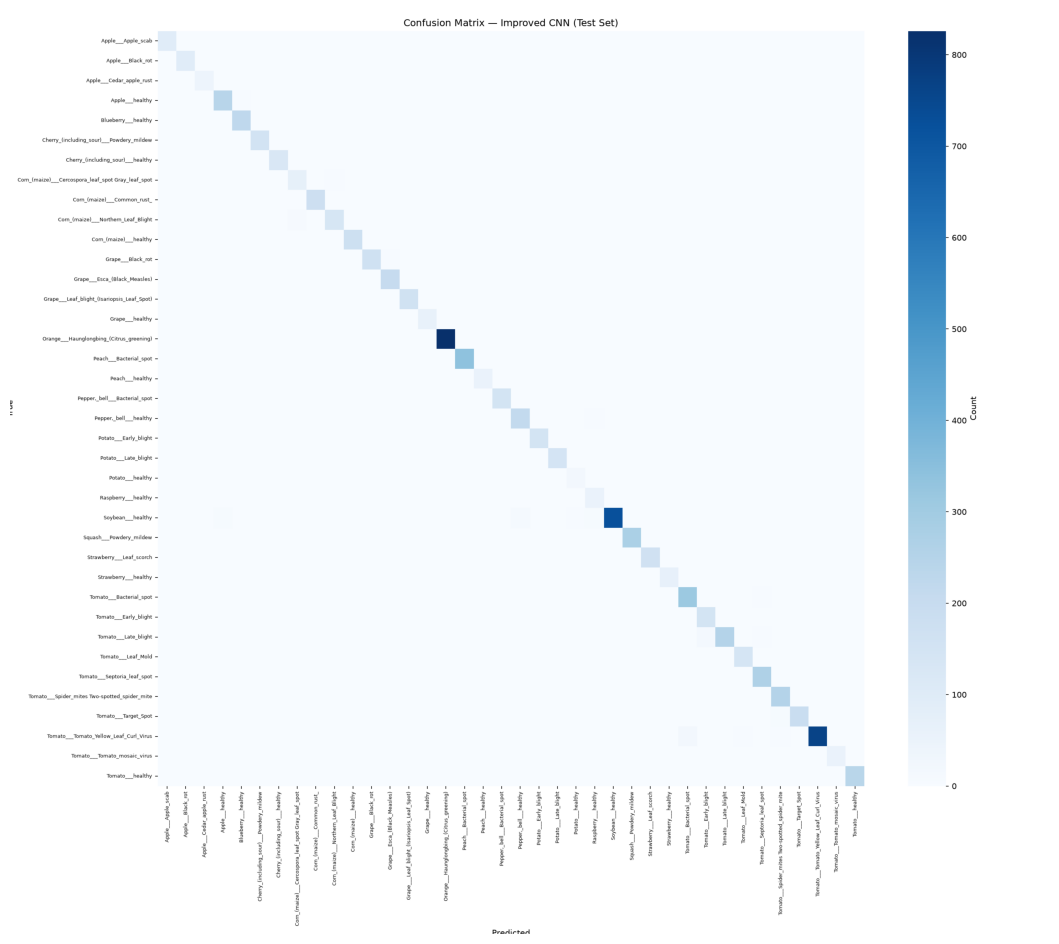

In [5]:
cm_path = PLOTS_DIR / 'confusion_matrix.png'
cm = plot_confusion_matrix(y_true, y_pred, class_names, cm_path)

from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(cm_path)
plt.figure(figsize=(14, 12))
plt.imshow(img)
plt.axis('off')
plt.show()


## 5. Top confused class pairs

In [6]:
print_top_confusions(cm, class_names, top_n=15)



Top 15 confused class pairs (true -> predicted : count):
  Tomato___Tomato_Yellow_Leaf_Curl_Virus        -> Tomato___Bacterial_spot                       : 25
  Tomato___Late_blight                          -> Tomato___Early_blight                         : 19
  Soybean___healthy                             -> Pepper,_bell___healthy                        : 15
  Corn_(maize)___Northern_Leaf_Blight           -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 12
  Soybean___healthy                             -> Apple___healthy                               : 8
  Soybean___healthy                             -> Raspberry___healthy                           : 7
  Tomato___Target_Spot                          -> Tomato___Spider_mites Two-spotted_spider_mite : 7
  Grape___Black_rot                             -> Grape___Esca_(Black_Measles)                  : 6
  Pepper,_bell___healthy                        -> Raspberry___healthy                           : 6
  Tomato___Tomato_Yellow

## 6. Save predictions CSV

In [7]:
preds_csv_path = METADATA_DIR / 'test_predictions.csv'
save_predictions_csv(y_true, y_pred, confidences, filepaths, idx_to_class, preds_csv_path)
print(f"Saved: {preds_csv_path}")


Saved: G:\Project CNN\data\metadata\test_predictions.csv
